<a href="https://colab.research.google.com/github/farzanamjad/HR-Employee-Attrition-Analysis/blob/main/HR_Employee_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

In [58]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (2).csv


In [59]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [60]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

First 5 Rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWo

In [ ]:
# Check duplicate rows

print("Number of duplicate rows:")
print(df.duplicated().sum())

In [61]:
# Check unique values in possible unnecessary columns

columns_to_check = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

for col in columns_to_check:
    print(f"\n{col}:")
    print(df[col].unique())


EmployeeCount:
[1]

EmployeeNumber:
[   1    2    4 ... 2064 2065 2068]

Over18:
['Y']

StandardHours:
[80]


In [62]:
# Remove columns that do not provide useful information for analysis

columns_to_remove = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df_clean = df.drop(columns=columns_to_remove)

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

Original dataset shape: (1470, 35)
Cleaned dataset shape: (1470, 31)

Remaining columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [63]:
# Separate numerical and categorical columns

numerical_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df_clean.select_dtypes(include=['object']).columns

print("Number of Numerical Columns:", len(numerical_columns))
print("\nNumerical Columns:")
print(list(numerical_columns))

print("\n" + "="*60)

print("\nNumber of Categorical Columns:", len(categorical_columns))
print("\nCategorical Columns:")
print(list(categorical_columns))

Number of Numerical Columns: 23

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Number of Categorical Columns: 8

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [64]:
print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [65]:
# Overall Employee Attrition

attrition_count = df_clean['Attrition'].value_counts()

print("Employee Attrition Count:")
print(attrition_count)

print("\nEmployee Attrition Percentage:")
print(df_clean['Attrition'].value_counts(normalize=True) * 100)

Employee Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Employee Attrition Percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


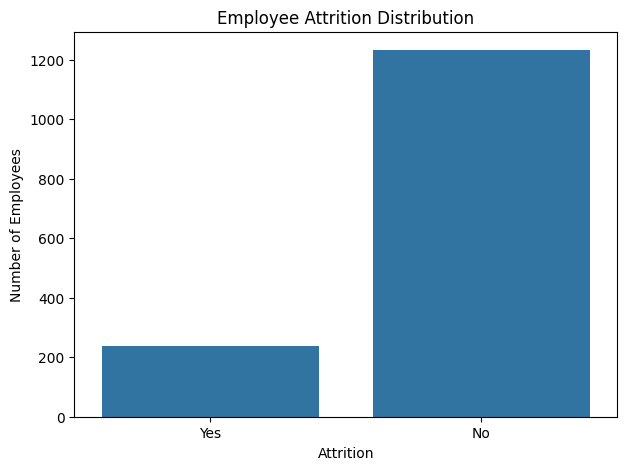

In [66]:
# Employee Attrition Distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x='Attrition')

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

plt.show()

In [67]:
# Department-wise Attrition Count

department_attrition = pd.crosstab(
    df_clean['Department'],
    df_clean['Attrition']
)

print(department_attrition)

Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


In [68]:
# Department-wise Attrition Percentage

department_attrition_pct = pd.crosstab(
    df_clean['Department'],
    df_clean['Attrition'],
    normalize='index'
) * 100

print(department_attrition_pct.round(2))

Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


In [69]:
# Department-wise Attrition Percentage

department_attrition_pct = pd.crosstab(
    df_clean['Department'],
    df_clean['Attrition'],
    normalize='index'
) * 100

print(department_attrition_pct.round(2))

Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


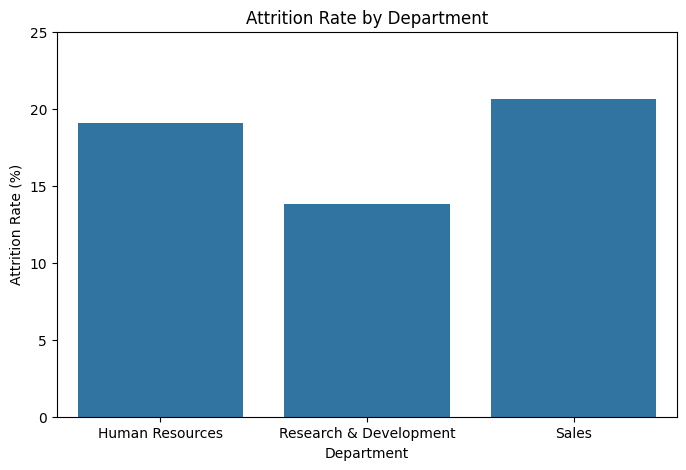

In [70]:
# Department-wise Attrition Rate

attrition_rate = department_attrition_pct['Yes'].reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=attrition_rate,
    x='Department',
    y='Yes'
)

plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')

plt.ylim(0, 25)

plt.show()

In [71]:
# Overtime vs Attrition Count

overtime_attrition = pd.crosstab(
    df_clean['OverTime'],
    df_clean['Attrition']
)

print(overtime_attrition)

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127


In [72]:
# Overtime vs Attrition Percentage

overtime_attrition_pct = pd.crosstab(
    df_clean['OverTime'],
    df_clean['Attrition'],
    normalize='index'
) * 100

print(overtime_attrition_pct.round(2))

Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53


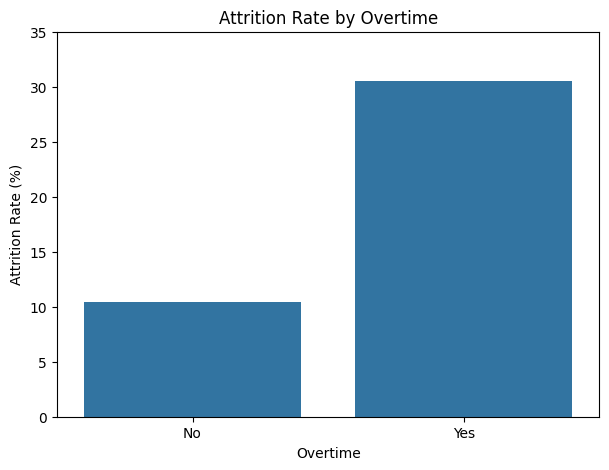

In [73]:
# Overtime vs Attrition Rate

overtime_rate = overtime_attrition_pct['Yes'].reset_index()

plt.figure(figsize=(7, 5))

sns.barplot(
    data=overtime_rate,
    x='OverTime',
    y='Yes'
)

plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')

plt.ylim(0, 35)

plt.show()

In [74]:
# Job Satisfaction vs Attrition

job_satisfaction_attrition = pd.crosstab(
    df_clean['JobSatisfaction'],
    df_clean['Attrition']
)

print(job_satisfaction_attrition)

Attrition         No  Yes
JobSatisfaction          
1                223   66
2                234   46
3                369   73
4                407   52


In [75]:
# Job Satisfaction vs Attrition Percentage

job_satisfaction_attrition_pct = pd.crosstab(
    df_clean['JobSatisfaction'],
    df_clean['Attrition'],
    normalize='index'
) * 100

print(job_satisfaction_attrition_pct.round(2))

Attrition           No    Yes
JobSatisfaction              
1                77.16  22.84
2                83.57  16.43
3                83.48  16.52
4                88.67  11.33


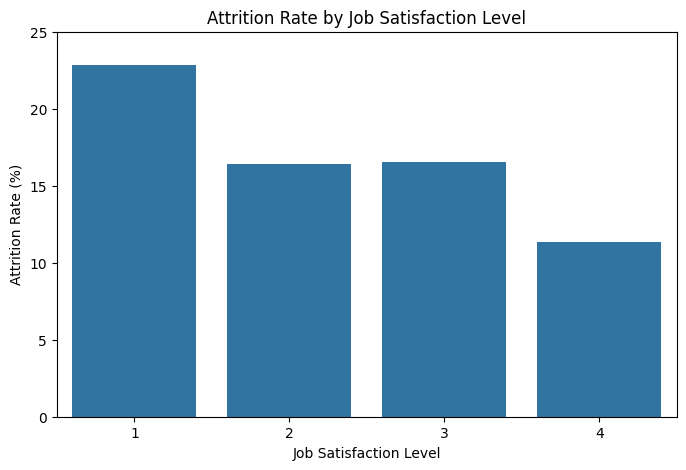

In [76]:
# Job Satisfaction vs Attrition Rate

job_satisfaction_rate = job_satisfaction_attrition_pct['Yes'].reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=job_satisfaction_rate,
    x='JobSatisfaction',
    y='Yes'
)

plt.title('Attrition Rate by Job Satisfaction Level')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Attrition Rate (%)')

plt.ylim(0, 25)

plt.show()

In [78]:
# Create age groups

df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[17, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

print(df_clean['AgeGroup'].value_counts().sort_index())

AgeGroup
18-25    123
26-35    606
36-45    468
46-55    226
56+       47
Name: count, dtype: int64


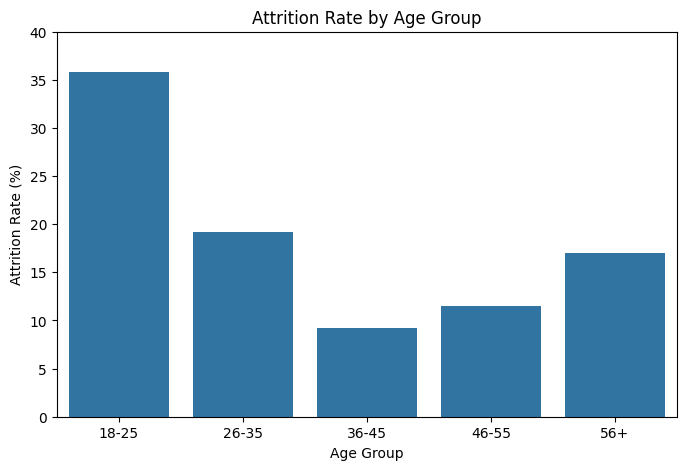

In [79]:
# Calculate Age Group vs Attrition Percentage
age_attrition_pct = pd.crosstab(
    df_clean['AgeGroup'],
    df_clean['Attrition'],
    normalize='index'
) * 100

# Age Group vs Attrition Rate
age_attrition_rate = age_attrition_pct['Yes'].reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=age_attrition_rate,
    x='AgeGroup',
    y='Yes'
)

plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')

plt.ylim(0, 40)

plt.show()

In [80]:
# Create Monthly Income Groups

df_clean['IncomeGroup'] = pd.qcut(
    df_clean['MonthlyIncome'],
    q=4,
    labels=['Low Income', 'Medium-Low Income', 'Medium-High Income', 'High Income']
)

print(df_clean['IncomeGroup'].value_counts().sort_index())

IncomeGroup
Low Income            369
Medium-Low Income     366
Medium-High Income    367
High Income           368
Name: count, dtype: int64


In [81]:
# Monthly Income Group vs Attrition Percentage

income_attrition_pct = pd.crosstab(
    df_clean['IncomeGroup'],
    df_clean['Attrition'],
    normalize='index'
) * 100

print(income_attrition_pct.round(2))

Attrition              No    Yes
IncomeGroup                     
Low Income          70.73  29.27
Medium-Low Income   85.79  14.21
Medium-High Income  89.37  10.63
High Income         89.67  10.33


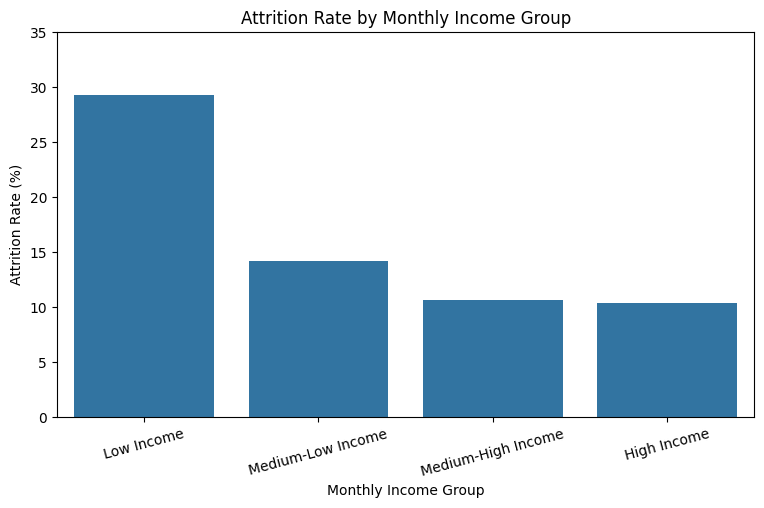

In [82]:
# Monthly Income Group vs Attrition Rate

income_attrition_rate = income_attrition_pct['Yes'].reset_index()

plt.figure(figsize=(9, 5))

sns.barplot(
    data=income_attrition_rate,
    x='IncomeGroup',
    y='Yes'
)

plt.title('Attrition Rate by Monthly Income Group')
plt.xlabel('Monthly Income Group')
plt.ylabel('Attrition Rate (%)')

plt.ylim(0, 35)

plt.xticks(rotation=15)

plt.show()

In [83]:
# Create Years at Company groups

df_clean['YearsAtCompanyGroup'] = pd.cut(
    df_clean['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 20, 100],
    labels=['0-2 Years', '3-5 Years', '6-10 Years', '11-20 Years', '21+ Years']
)

print(df_clean['YearsAtCompanyGroup'].value_counts().sort_index())

YearsAtCompanyGroup
0-2 Years      342
3-5 Years      434
6-10 Years     448
11-20 Years    180
21+ Years       66
Name: count, dtype: int64


In [84]:
# Years at Company vs Attrition Percentage

years_attrition_pct = pd.crosstab(
    df_clean['YearsAtCompanyGroup'],
    df_clean['Attrition'],
    normalize='index'
) * 100

print(years_attrition_pct.round(2))

Attrition               No    Yes
YearsAtCompanyGroup              
0-2 Years            70.18  29.82
3-5 Years            86.18  13.82
6-10 Years           87.72  12.28
11-20 Years          93.33   6.67
21+ Years            87.88  12.12


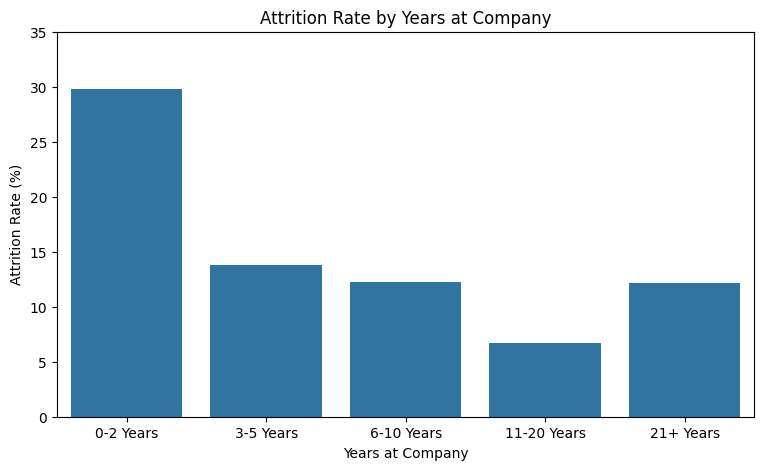

In [85]:
# Years at Company vs Attrition Rate

years_attrition_rate = years_attrition_pct['Yes'].reset_index()

plt.figure(figsize=(9, 5))

sns.barplot(
    data=years_attrition_rate,
    x='YearsAtCompanyGroup',
    y='Yes'
)

plt.title('Attrition Rate by Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')

plt.ylim(0, 35)

plt.show()

In [86]:
# Job Role vs Attrition Percentage

jobrole_attrition_pct = pd.crosstab(
    df_clean['JobRole'],
    df_clean['Attrition'],
    normalize='index'
) * 100

print(jobrole_attrition_pct.round(2).sort_values('Yes', ascending=False))

Attrition                     No    Yes
JobRole                                
Sales Representative       60.24  39.76
Laboratory Technician      76.06  23.94
Human Resources            76.92  23.08
Sales Executive            82.52  17.48
Research Scientist         83.90  16.10
Manufacturing Director     93.10   6.90
Healthcare Representative  93.13   6.87
Manager                    95.10   4.90
Research Director          97.50   2.50


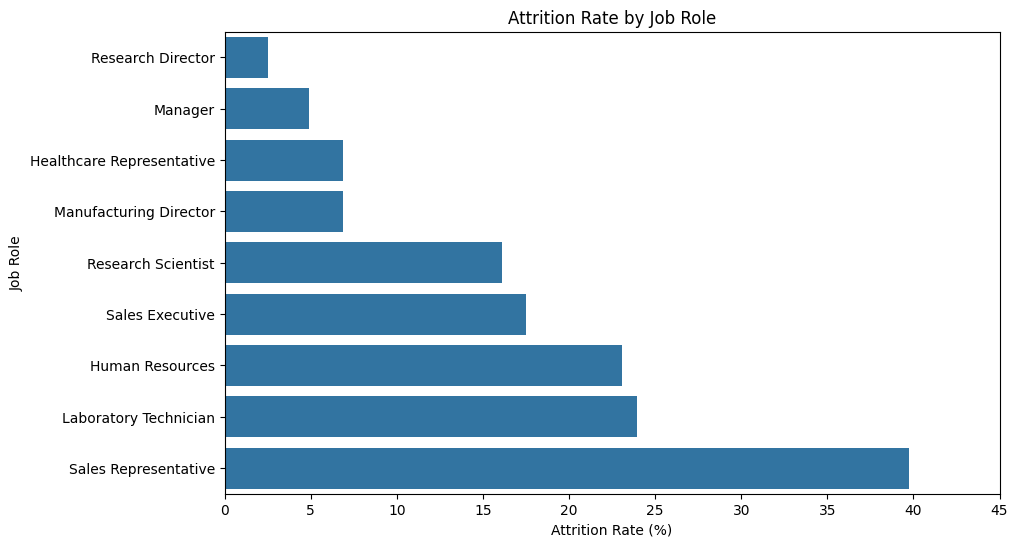

In [87]:
# Job Role vs Attrition Rate

jobrole_attrition_rate = (
    jobrole_attrition_pct['Yes']
    .sort_values(ascending=True)
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=jobrole_attrition_rate,
    x='Yes',
    y='JobRole'
)

plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')

plt.xlim(0, 45)

plt.show()

In [88]:
# Business Travel vs Attrition Percentage

travel_attrition_pct = pd.crosstab(
    df_clean['BusinessTravel'],
    df_clean['Attrition'],
    normalize='index'
) * 100

print(travel_attrition_pct.round(2))

Attrition             No    Yes
BusinessTravel                 
Non-Travel         92.00   8.00
Travel_Frequently  75.09  24.91
Travel_Rarely      85.04  14.96


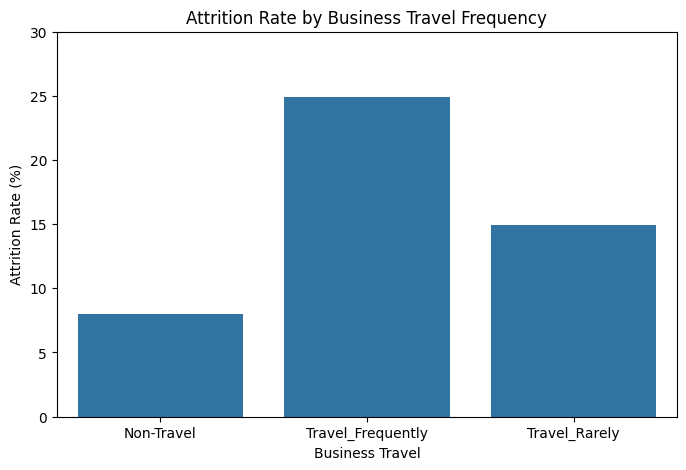

In [89]:
# Business Travel vs Attrition Rate

travel_attrition_rate = travel_attrition_pct['Yes'].reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=travel_attrition_rate,
    x='BusinessTravel',
    y='Yes'
)

plt.title('Attrition Rate by Business Travel Frequency')
plt.xlabel('Business Travel')
plt.ylabel('Attrition Rate (%)')

plt.ylim(0, 30)

plt.show()

In [90]:
# Work-Life Balance vs Attrition Percentage

worklife_attrition_pct = pd.crosstab(
    df_clean['WorkLifeBalance'],
    df_clean['Attrition'],
    normalize='index'
) * 100

print(worklife_attrition_pct.round(2))

Attrition           No    Yes
WorkLifeBalance              
1                68.75  31.25
2                83.14  16.86
3                85.78  14.22
4                82.35  17.65


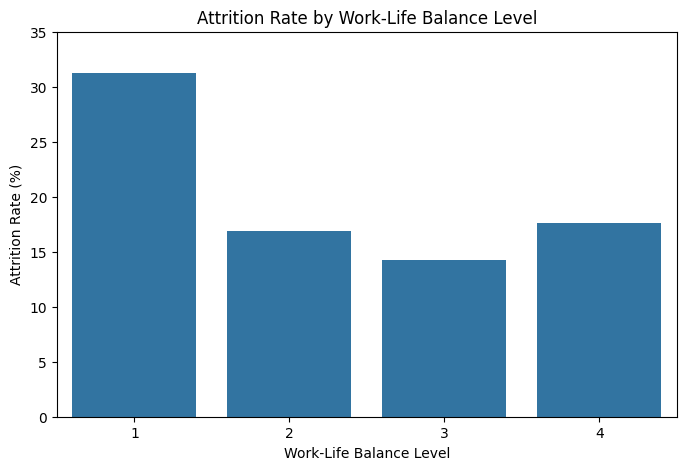

In [91]:
# Work-Life Balance vs Attrition Rate

worklife_attrition_rate = worklife_attrition_pct['Yes'].reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=worklife_attrition_rate,
    x='WorkLifeBalance',
    y='Yes'
)

plt.title('Attrition Rate by Work-Life Balance Level')
plt.xlabel('Work-Life Balance Level')
plt.ylabel('Attrition Rate (%)')

plt.ylim(0, 35)

plt.show()

In [92]:
# Job Level vs Attrition Percentage

joblevel_attrition_pct = pd.crosstab(
    df_clean['JobLevel'],
    df_clean['Attrition'],
    normalize='index'
) * 100

print(joblevel_attrition_pct.round(2))

Attrition     No    Yes
JobLevel               
1          73.66  26.34
2          90.26   9.74
3          85.32  14.68
4          95.28   4.72
5          92.75   7.25


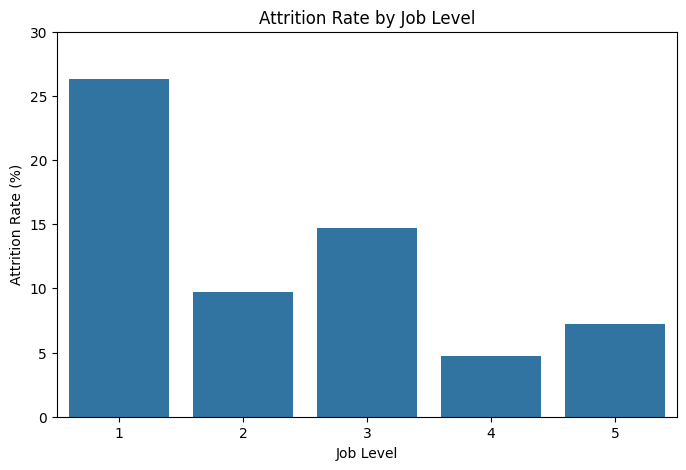

In [93]:
# Job Level vs Attrition Rate

joblevel_attrition_rate = joblevel_attrition_pct['Yes'].reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=joblevel_attrition_rate,
    x='JobLevel',
    y='Yes'
)

plt.title('Attrition Rate by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Attrition Rate (%)')

plt.ylim(0, 30)

plt.show()

In [95]:
# Convert Attrition to numeric for correlation analysis

df_clean['AttritionNumeric'] = df_clean['Attrition'].map({
    'No': 0,
    'Yes': 1
})

print(df_clean[['Attrition', 'AttritionNumeric']].head())

  Attrition  AttritionNumeric
0       Yes                 1
1        No                 0
2       Yes                 1
3        No                 0
4        No                 0


In [96]:
# Correlation of numerical features with Attrition

correlation_with_attrition = (
    df_clean.select_dtypes(include=['int64', 'float64'])
    .corr()['AttritionNumeric']
    .drop('AttritionNumeric')
    .sort_values()
)

print("Correlation with Attrition:")
print(correlation_with_attrition.round(3))

Correlation with Attrition:
TotalWorkingYears          -0.171
JobLevel                   -0.169
YearsInCurrentRole         -0.161
MonthlyIncome              -0.160
Age                        -0.159
YearsWithCurrManager       -0.156
StockOptionLevel           -0.137
YearsAtCompany             -0.134
JobInvolvement             -0.130
JobSatisfaction            -0.103
EnvironmentSatisfaction    -0.103
WorkLifeBalance            -0.064
TrainingTimesLastYear      -0.059
DailyRate                  -0.057
RelationshipSatisfaction   -0.046
YearsSinceLastPromotion    -0.033
Education                  -0.031
PercentSalaryHike          -0.013
HourlyRate                 -0.007
PerformanceRating           0.003
MonthlyRate                 0.015
NumCompaniesWorked          0.043
DistanceFromHome            0.078
Name: AttritionNumeric, dtype: float64


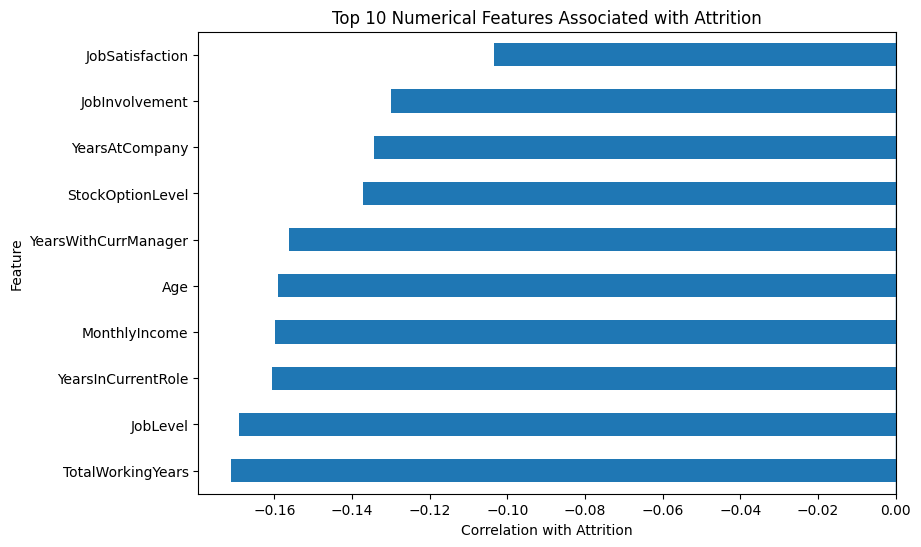

In [97]:
# Top Numerical Features Correlated with Attrition

top_correlations = correlation_with_attrition.abs().sort_values(
    ascending=False
).head(10)

top_features = correlation_with_attrition.loc[
    top_correlations.index
].sort_values()

plt.figure(figsize=(9, 6))

top_features.plot(kind='barh')

plt.title('Top 10 Numerical Features Associated with Attrition')
plt.xlabel('Correlation with Attrition')
plt.ylabel('Feature')

plt.axvline(0, linewidth=1)

plt.show()

In [98]:
# STEP 17A - Prepare data for Machine Learning

# Create a copy of the cleaned dataset
ml_df = df_clean.copy()

# Remove EDA-only columns that we don't need for the model
ml_df = ml_df.drop(
    columns=[
        'AttritionNumeric',
        'AgeGroup',
        'IncomeGroup',
        'YearsAtCompanyGroup'
    ],
    errors='ignore'
)

# Separate target and features
X = ml_df.drop(columns=['Attrition'])
y = ml_df['Attrition'].map({
    'No': 0,
    'Yes': 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values:")
print(X.isnull().sum().sum())

Feature shape: (1470, 30)
Target shape: (1470,)

Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Missing values:
0


In [99]:
# STEP 17B - Train/Test Split and Categorical Encoding

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumber of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', 'passthrough', numerical_features)
    ]
)

print("\nPreprocessor created successfully.")

Categorical Features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Number of Numerical Features: 23
Number of Categorical Features: 7

Training Data Shape: (1176, 30)
Testing Data Shape: (294, 30)

Training Target Distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

Testing Target Distribution:
Attrition
0    247
1     47
Name: count, dtype: int64

Preprocessor created successfully.


In [100]:
# STEP 18 - Logistic Regression Model

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Calculate metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("=" * 35)

print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1 Score : {f1_logistic:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=['Stayed', 'Left']
))

Logistic Regression Results
Accuracy : 0.7415
Precision: 0.3474
Recall   : 0.7021
F1 Score : 0.4648

Confusion Matrix:
[[185  62]
 [ 14  33]]

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.93      0.75      0.83       247
        Left       0.35      0.70      0.46        47

    accuracy                           0.74       294
   macro avg       0.64      0.73      0.65       294
weighted avg       0.84      0.74      0.77       294



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [101]:
# STEP 18A - Fix Logistic Regression using Feature Scaling

from sklearn.preprocessing import StandardScaler

# Recreate the preprocessor with scaling for numerical features
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            StandardScaler(),
            numerical_features
        )
    ]
)

# Create improved Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

# Train
logistic_model.fit(X_train, y_train)

# Predict
y_pred_logistic = logistic_model.predict(X_test)

# Evaluation
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Improved Logistic Regression Results")
print("=" * 40)

print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1 Score : {f1_logistic:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=['Stayed', 'Left']
))

Improved Logistic Regression Results
Accuracy : 0.7517
Precision: 0.3488
Recall   : 0.6383
F1 Score : 0.4511

Confusion Matrix:
[[191  56]
 [ 17  30]]

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.77      0.84       247
        Left       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294



In [102]:
# STEP 19 - Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree pipeline
decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            max_depth=5,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = decision_tree_model.predict(X_test)

# Calculate metrics
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("=" * 35)

print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1 Score : {f1_tree:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=['Stayed', 'Left']
))

Decision Tree Results
Accuracy : 0.7823
Precision: 0.3731
Recall   : 0.5319
F1 Score : 0.4386

Confusion Matrix:
[[205  42]
 [ 22  25]]

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.83      0.86       247
        Left       0.37      0.53      0.44        47

    accuracy                           0.78       294
   macro avg       0.64      0.68      0.65       294
weighted avg       0.82      0.78      0.80       294



In [103]:
# STEP 20 - Random Forest Model

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("=" * 35)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Stayed', 'Left']
))

Random Forest Results
Accuracy : 0.8435
Precision: 0.5217
Recall   : 0.2553
F1 Score : 0.3429

Confusion Matrix:
[[236  11]
 [ 35  12]]

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.96      0.91       247
        Left       0.52      0.26      0.34        47

    accuracy                           0.84       294
   macro avg       0.70      0.61      0.63       294
weighted avg       0.82      0.84      0.82       294



In [104]:
# STEP 21 - Model Comparison

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf
    ],
    'Precision': [
        precision_logistic,
        precision_tree,
        precision_rf
    ],
    'Recall': [
        recall_logistic,
        recall_tree,
        recall_rf
    ],
    'F1 Score': [
        f1_logistic,
        f1_tree,
        f1_rf
    ]
})

print(model_comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.7517     0.3488  0.6383    0.4511
1        Decision Tree    0.7823     0.3731  0.5319    0.4386
2        Random Forest    0.8435     0.5217  0.2553    0.3429


In [105]:
# STEP 21 - Model Comparison

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf
    ],
    'Precision': [
        precision_logistic,
        precision_tree,
        precision_rf
    ],
    'Recall': [
        recall_logistic,
        recall_tree,
        recall_rf
    ],
    'F1 Score': [
        f1_logistic,
        f1_tree,
        f1_rf
    ]
})

print(model_comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.7517     0.3488  0.6383    0.4511
1        Decision Tree    0.7823     0.3731  0.5319    0.4386
2        Random Forest    0.8435     0.5217  0.2553    0.3429


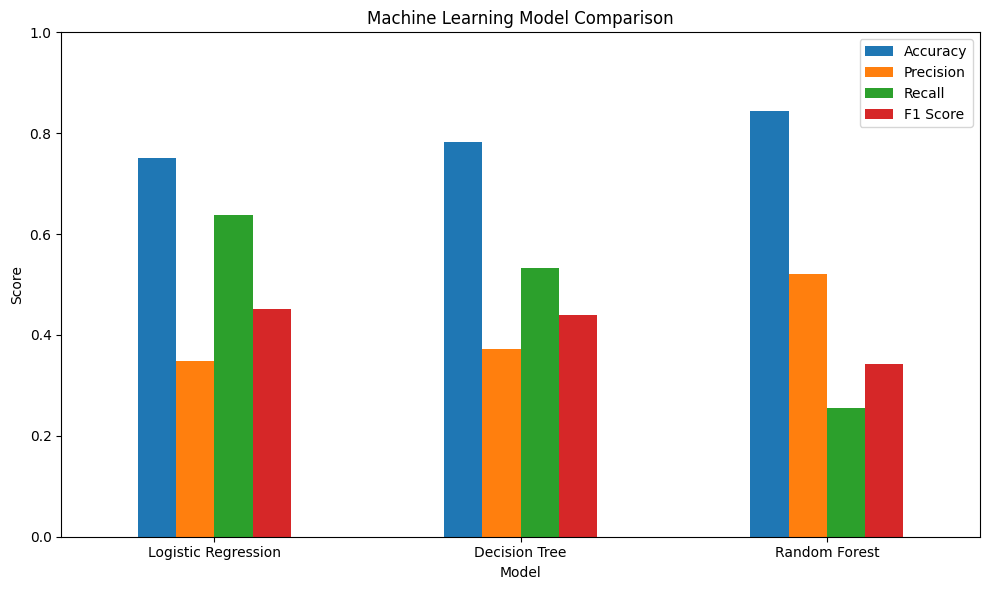

In [106]:
# STEP 21B - Model Comparison Graph

model_comparison.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    kind='bar',
    figsize=(10, 6)
)

plt.title('Machine Learning Model Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

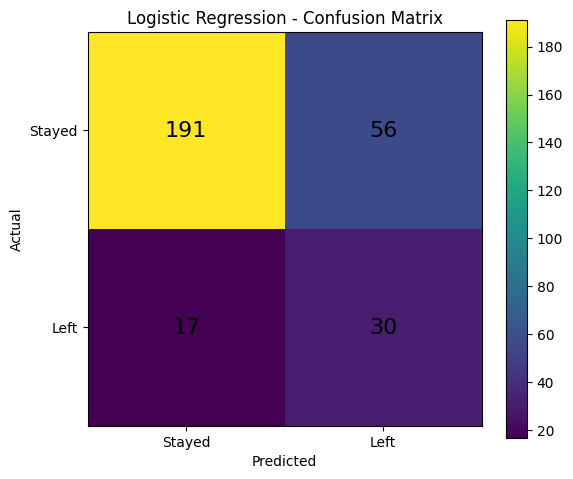

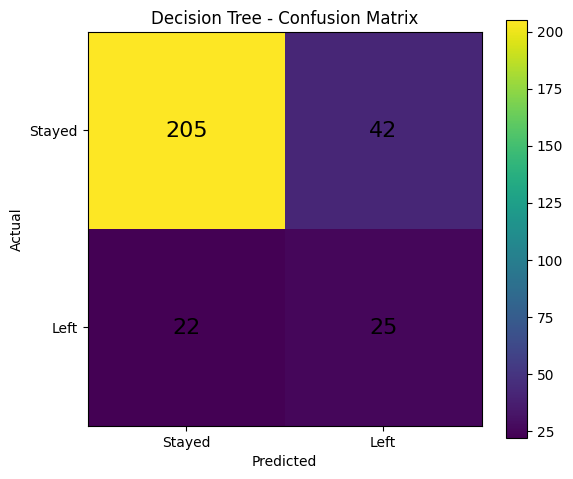

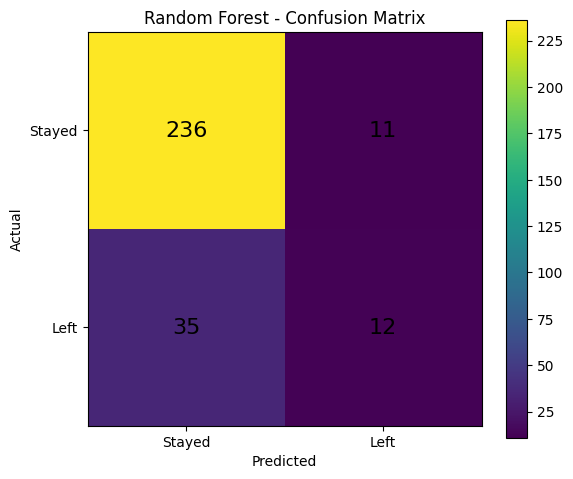

In [108]:
# STEP 22 - Confusion Matrix Comparison

import matplotlib.pyplot as plt

# Confusion matrices
cm_logistic = [[191, 56],
               [17, 30]]

cm_tree = [[205, 42],
           [22, 25]]

cm_rf = [[236, 11],
         [35, 12]]

# Store matrices
matrices = [
    ("Logistic Regression", cm_logistic),
    ("Decision Tree", cm_tree),
    ("Random Forest", cm_rf)
]

# Create 3 separate graphs
for name, cm in matrices:

    plt.figure(figsize=(6, 5))

    plt.imshow(cm)

    plt.title(name + " - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks([0, 1], ["Stayed", "Left"])
    plt.yticks([0, 1], ["Stayed", "Left"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i][j],
                ha="center",
                va="center",
                fontsize=16
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

We analyzed employee attrition using data analysis and machine learning. Overtime, age, income, job role, business travel, and years at company showed important differences in attrition. We tested Logistic Regression, Decision Tree, and Random Forest. Random Forest had the highest accuracy (84.35%), but Logistic Regression had the highest recall (63.83%). Since our goal is to identify employees who may leave, Logistic Regression is more useful for this HR project.